# Required imports
Always run

In [1]:
import os
import glob

import numpy as np
import matplotlib.pyplot as plt

import librosa
from scipy.fftpack import dct

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, GaussianNoise, Reshape
from tensorflow.keras.layers import GlobalAveragePooling1D

# Load dataset and extract MFCC features

In [2]:
# Load dataset

dataset_path = "dataset"

train_dir = os.path.join(dataset_path, "training")
test_dir = os.path.join(dataset_path, "testing")

def load_dataset(folder):
    file_paths = []
    labels = []

    wav_files = glob.glob(os.path.join(folder, "*.wav"))

    for file in wav_files:
        filename = os.path.basename(file)

        # label = parte prima del primo punto
        label = filename.split(".")[0]

        file_paths.append(file)
        labels.append(label)

    return file_paths, labels


X_train_paths, y_train = load_dataset(train_dir)
X_test_paths, y_test = load_dataset(test_dir)

print("Training samples:", len(X_train_paths))
print("Testing samples:", len(X_test_paths))

print("Esempio:")
print(X_train_paths[0], "->", y_train[0])

lookup = tf.keras.layers.StringLookup(output_mode="one_hot", num_oov_indices=0)
lookup.adapt(y_train)

y_train = lookup(y_train)
y_test = lookup(y_test)

labels = lookup.get_vocabulary()
num_classes = len(labels)

print("Classi:", labels)
print(X_train_paths[0], "->", y_train[0])

Training samples: 2615
Testing samples: 641
Esempio:
dataset\training\heynano.6ijighc8.ingestion-5b8c4cd96d-2ckxk.s1.wav -> heynano
Classi: ['noise', 'unknown', 'heynano', 'on', 'off']
dataset\training\heynano.6ijighc8.ingestion-5b8c4cd96d-2ckxk.s1.wav -> tf.Tensor([0 0 1 0 0], shape=(5,), dtype=int64)


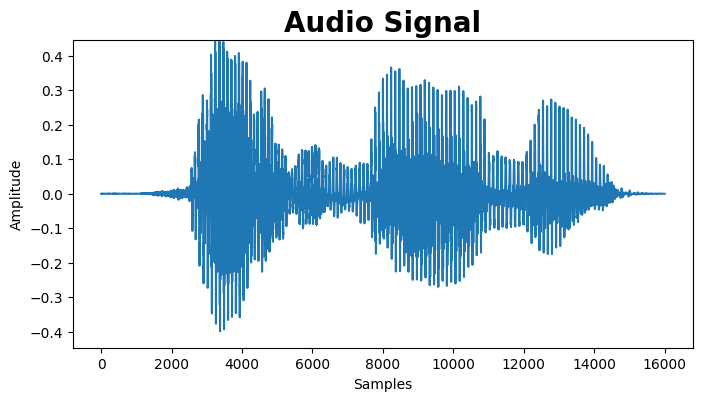

In [3]:
# Plot audio signal

audio, sr = librosa.load(X_train_paths[0], sr=16000)

max_val = np.max(np.abs(audio))

plt.figure(figsize=(8,4))
plt.plot(audio)
plt.title("Audio Signal", fontsize=20, fontweight='bold')
plt.ylim(-max_val, max_val)

plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

In [4]:
# MFCC

# Parameters similar to Edge Impulse
N_MFCC = 13
FRAME_LENGTH = 0.025
FRAME_STRIDE = 0.02
N_FFT = 512
N_MELS = 32
FMIN = 80
PRE_EMPHASIS = 0.98


def extract_mfcc(file_path):

    # carica audio (1 secondo, 16kHz)
    audio, sr = librosa.load(file_path, sr=None)

    # --- PRE-EMPHASIS ---
    emphasized = np.append(audio[0], audio[1:] - PRE_EMPHASIS * audio[:-1])

    # --- FRAMING ---
    frame_length = int(FRAME_LENGTH * sr)
    frame_step = int(FRAME_STRIDE * sr)

    signal_length = len(emphasized)

    num_frames = int(
        np.ceil(float(np.abs(signal_length - frame_length)) / frame_step)
    ) + 1

    pad_signal_length = num_frames * frame_step + frame_length
    z = np.zeros((pad_signal_length - signal_length))
    pad_signal = np.append(emphasized, z)

    indices = (
        np.tile(np.arange(0, frame_length), (num_frames, 1))
        + np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T
    )

    frames = pad_signal[indices.astype(np.int32, copy=False)]

    # finestra Hamming
    frames *= np.hamming(frame_length)

    # --- FFT ---
    mag_frames = np.absolute(np.fft.rfft(frames, N_FFT))

    # --- POWER SPECTRUM ---
    pow_frames = (1.0 / N_FFT) * (mag_frames ** 2)

    # --- MEL FILTERBANK ---
    mel_filter = librosa.filters.mel(
        sr=sr,
        n_fft=N_FFT,
        n_mels=N_MELS,
        fmin=FMIN
    )

    mel_energy = np.dot(pow_frames, mel_filter.T)

    # evita log(0)
    mel_energy = np.where(mel_energy == 0, np.finfo(float).eps, mel_energy)

    # --- LOG ---
    log_mel = np.log(mel_energy)

    return log_mel.astype(np.float32)
    # --- DCT ---
    #mfcc = dct(log_mel, type=2, axis=1, norm='ortho')[:, :N_MFCC]

    #return mfcc.astype(np.float32)  # shape (50,13)


X_train = []
X_test = []

for file in X_train_paths:
    mfcc = extract_mfcc(file)
    X_train.append(mfcc)

for file in X_test_paths:
    mfcc = extract_mfcc(file)
    X_test.append(mfcc)

X_train = np.array(X_train)
X_test = np.array(X_test)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (2615, 50, 32)
Shape X_test: (641, 50, 32)


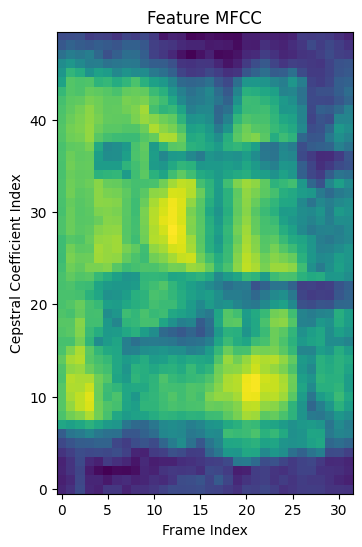

In [6]:
# Plot MFCC
plt.figure(figsize=(10,6))
plt.imshow(X_train[0], cmap='viridis', origin='lower')
plt.title("Feature MFCC")
plt.xlabel("Frame Index")
plt.ylabel("Cepstral Coefficient Index")
plt.show()

In [ ]:
import wave, struct, numpy as np

WAV_PATH = X_train_paths[0]
TARGET_SAMPLES = 16000

with wave.open(WAV_PATH, 'r') as wf:
    assert wf.getframerate() == 16000, "Resample to 16 kHz first"
    assert wf.getsampwidth() == 2,     "Must be 16-bit PCM"
    raw = wf.readframes(wf.getnframes())

samples = np.frombuffer(raw, dtype=np.int16)

# mono: take left channel if stereo
if wf.getnchannels() == 2:
    samples = samples[::2]

# pad or trim to exactly 16000 samples
if len(samples) < TARGET_SAMPLES:
    samples = np.pad(samples, (0, TARGET_SAMPLES - len(samples)))
else:
    samples = samples[:TARGET_SAMPLES]

# emit C array
vals = ", ".join(str(v) for v in samples.tolist())
print(f"static const short testAudio[{TARGET_SAMPLES}] = {{{vals}}};")
print("a capo")

In [ ]:
# print first mfcc feature vector
print(X_train[0])

In [7]:
# NORMALIZZAZIONE
mean = np.mean(X_train, axis=(0,1))
std = np.std(X_train, axis=(0,1)) + 1e-8

# Print values needed for normalization on arduino
print("Mean:", mean)
print("Std:", std)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

Mean: [-17.819597 -17.59074  -17.480047 -17.322508 -17.22088  -17.20256
 -17.192617 -17.216824 -17.255072 -17.279606 -17.334177 -17.485449
 -17.512192 -17.52648  -17.543146 -17.602314 -17.623314 -17.642267
 -17.667725 -17.620695 -17.460741 -17.45068  -17.43203  -17.423262
 -17.657875 -17.928747 -18.13429  -18.290573 -18.52341  -18.67179
 -18.760841 -19.359491]
Std: [5.3582873 5.4376783 5.526304  5.6093426 5.6271577 5.6333036 5.54719
 5.415111  5.331926  5.287388  5.2071757 5.1123886 5.027969  4.9369555
 4.8512278 4.757777  4.7120786 4.7416825 4.7746954 4.807016  4.8529115
 4.848371  4.863014  4.8709044 4.738505  4.5517983 4.4268384 4.3711224
 4.3133655 4.2613163 4.281444  4.3504925]


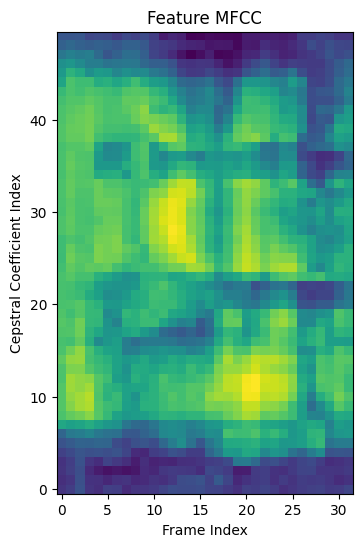

In [9]:
# Plot MFCC
plt.figure(figsize=(10,6))
plt.imshow(X_train[0], cmap='viridis', origin='lower')
plt.title("Feature MFCC")
plt.xlabel("Frame Index")
plt.ylabel("Cepstral Coefficient Index")
plt.show()

In [ ]:
# Save features
np.savez("features/features.npz", X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)

# Train model

In [ ]:
# Load feature
data = np.load("features/features.npz")

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

In [10]:
EPOCHS = 100
BATCH_SIZE = 32
num_classes = 5

# flatten
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

# dimensione del validation set
val_size = int(0.2 * len(X_train))

# shuffle prima di dividere
train_dataset = train_dataset.shuffle(buffer_size=len(X_train), seed=42)

val_dataset = train_dataset.take(val_size)
train_dataset = train_dataset.skip(val_size)

# batching
train_dataset = train_dataset.batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)

# Test 8 - CNN
model = Sequential()
model.add(tf.keras.Input(shape=(1600,)))
model.add(GaussianNoise(0.2))
model.add(Reshape((50, 32)))
model.add(Conv1D(8, kernel_size=5, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
model.add(Dropout(0.25))
model.add(Conv1D(16, kernel_size=5, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
model.add(Dropout(0.25))
model.add(GlobalAveragePooling1D())
model.add(Dense(num_classes, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 50, 8)          │         1,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 25, 16)         │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,029 (7.93 KB)

 Trainable params: 2,029 (7.93 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# print first sample of X_train
np.set_printoptions(suppress=True, precision=4)
print(X_train[0])

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3160 - loss: 1.5391 - val_accuracy: 0.4646 - val_loss: 1.3449
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4871 - loss: 1.2664 - val_accuracy: 0.6119 - val_loss: 1.1891
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5535 - loss: 1.1307 - val_accuracy: 0.5985 - val_loss: 1.0706
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6085 - loss: 1.0378 - val_accuracy: 0.6616 - val_loss: 0.9036
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6496 - loss: 0.9595 - val_accuracy: 0.6845 - val_loss: 0.8907
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6711 - loss: 0.8925 - val_accuracy: 0.7400 - val_loss: 0.7648
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6716 - loss: 0.8735 - val_accuracy: 0.7342 - val_loss: 0.8121
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6926 - loss: 0.8357 - val_accuracy: 0.7304 - 

In [13]:
# Valutazione
test_loss, test_acc = model.evaluate(test_dataset)

print("Test accuracy:", test_acc)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8939 - loss: 0.3194
Test accuracy: 0.8939157724380493


In [14]:
# Save model
model.save("models/best2.keras")

# Quantization

In [ ]:
# Load model
# model = tf.keras.models.load_model("models/best.keras")

In [15]:
# Convert to TFLite full int8
def representative_dataset():
    idx = np.random.choice(len(X_train), 300, replace=False)
    for i in idx:
        data = X_train[i].astype(np.float32)
        data = np.expand_dims(data, axis=0)
        yield [data]

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

save_path = "models/best2.tflite"

with open(save_path, "wb") as f:
    f.write(tflite_quant_model)

print("Modello salvato in:", save_path)

INFO:tensorflow:Assets written to: C:\Users\nicol\AppData\Local\Temp\tmpc0an3j2v\assets


INFO:tensorflow:Assets written to: C:\Users\nicol\AppData\Local\Temp\tmpc0an3j2v\assets


Saved artifact at 'C:\Users\nicol\AppData\Local\Temp\tmpc0an3j2v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1600), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  1698445999568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1698445999184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1698465302480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1698465303056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1698465303248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1698465303440: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\nicol\Downloads\KWS\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Modello salvato in: models/best2.tflite


In [16]:
# Controllo dimensione del modello quantizzato
import os
size_kb = os.path.getsize("models/best.tflite") / 1024
print("Dimensione modello:", round(size_kb,2), "KB")

Dimensione modello: 8.66 KB


In [17]:
# Controllo dimensione del modello quantizzato
import os
size_kb = os.path.getsize("models/best2.tflite") / 1024
print("Dimensione modello:", round(size_kb,2), "KB")

Dimensione modello: 9.31 KB


In [ ]:
# convert the tflite model to a C array (we use git bash on windows, so we can use xxd command)
# xxd -i best.tflite > model_data.cc

In [ ]:
# inside Arduino libraries folder on your system
# git clone https://github.com/tensorflow/tflite-micro-arduino-examples Arduino_TensorFlowLite